# Predicting Employment Status Among Foreign-Born Individuals in the United States
## Using 2024 American Community Survey Data

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv("usa_00002.csv.gz", compression="gzip")

df.head()

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,REGION,GQ,PERNUM,PERWT,...,OCC,QAGE,QSEX,QBPL,QLANGUAG,QSPEAKEN,QYRIMM,QEDUC,QEMPSTAT,QOCC
0,2024,202401,1,2024010000060,41.0,2024000000011,32,3,1,41.0,...,8300,0,0,4,0,0,0,4,0,4
1,2024,202401,2,2024010000094,52.0,2024000000021,32,3,1,52.0,...,0,0,0,0,0,0,0,0,0,0
2,2024,202401,3,2024010000146,31.0,2024000000031,32,3,1,31.0,...,0,0,0,0,0,0,0,0,0,0
3,2024,202401,4,2024010000156,4.0,2024000000041,32,4,1,4.0,...,7010,0,0,0,0,0,0,0,0,0
4,2024,202401,5,2024010000182,19.0,2024000000051,32,3,1,19.0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Confirm 2024 data 
df['YEAR'].value_counts()

YEAR
2024    3422888
Name: count, dtype: int64

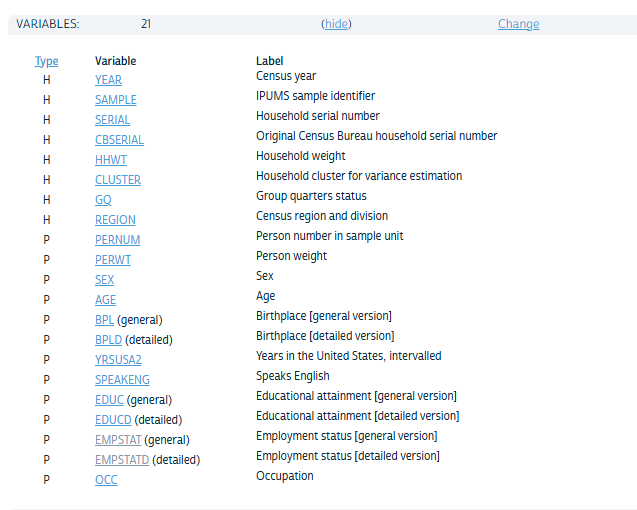

List of Selected Variables:
1. **EMPSTAT**: EMPSTAT indicates whether the respondent was a part of the labor force -- working or seeking work -- and, if so, whether the person was currently unemployed. The second digit preserves additional related information available for some years but not others. See LABFORCE for a dichotomous variable that identifies whether a person participated in the labor force or not and is available for all years in the IPUMS.
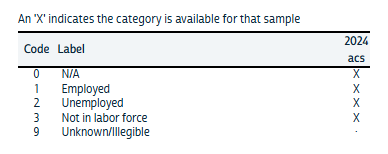  
2. **AGE**: AGE reports the person's age in years as of the last birthday.
3. **SEX**: SEX reports whether the person was male or female. 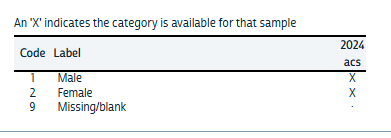
4. **EDUC**: EDUC indicates respondents' educational attainment, as measured by the highest year of school or degree completed. Note that completion differs from the highest year of school attendance; for example, respondents who attended 10th grade but did not finish were classified in EDUC as having completed 9th grade. For additional detail on grade attendance, see GRADEATT as well as the detailed version of HIGRADE.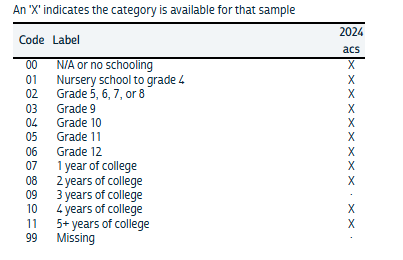
5. **YRUSA2**: YRSUSA2 reports how long a person who was born in a foreign country or U.S. outlying area had been living in the United States. 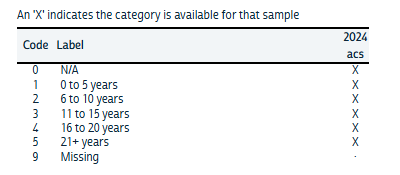
6. **SPEAKENG**: SPEAKENG indicates whether the respondent was able to speak English in 1900-1930 and 1970. Beginning in 1980, SPEAKENG indicates whether the respondent speaks only English at home, and also reports how well the respondent, who speaks a language other than English at home, speaks English.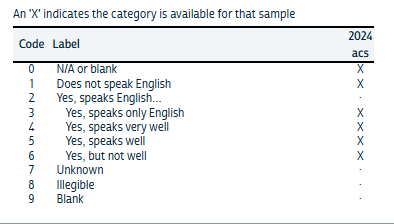
7. **OCC**: OCC reports the person's primary occupation, coded into a contemporary census classification scheme (some non-occupational activities are also recorded in the pre-1940 samples). Generally, the primary occupation is the one from which the person earns the most money; if respondents were not sure about this, they were to report the one at which they spent the most time. Unemployed persons were to give their most recent occupation. For persons listing more than one occupation, the samples use the first one listed. Link: https://usa.ipums.org/usa/volii/occ2018.shtml
8. **BPL**: BPL indicates the U.S. state, the outlying U.S. area or territory, or the foreign country where the person was born. Link: https://usa.ipums.org/usa-action/variables/BPL#codes_section
9. **REGION**: REGION identifies the region and division where the housing unit was located. Unless otherwise noted in the comparability discussion, states, or territories that later became states, are recoded into the following 1990 regional and divisional classification system:
- Northeast Region
New England Division: Connecticut, Maine, Massachusetts, New Hampshire, Rhode Island, Vermont
Middle Atlantic Division: New Jersey, New York, Pennsylvania
- Midwest (formerly North Central) Region
East North Central Division: Illinois, Indiana, Michigan, Ohio, Wisconsin
West North Central Division: Iowa, Kansas, Minnesota, Missouri, Nebraska, North Dakota, South Dakota
- South Region
South Atlantic Division: Delaware, District of Columbia, Florida, Georgia, Maryland, North Carolina, South Carolina, Virginia, West Virginia
East South Central Division: Alabama, Kentucky, Mississippi, Tennessee
West South Central Division: Arkansas, Louisiana, Oklahoma/Indian Territory, Texas
- West Region
Mountain Division: Arizona, Colorado, Idaho, Montana, Nevada, New Mexico, Utah, Wyoming
Pacific Division: Alaska, California, Hawaii, Oregon, Washington
- State Unknown. 1900-1910: overseas military reservations are not identified by state.
1980-1990: to protect confidentiality, state cannot be identified for PUMAs or county groups that cross state boundaries.


## Data Preparation

In [4]:
# keep only variables needed 
cols = [
    'AGE', 'SEX', 'BPL', 'EDUC', 'SPEAKENG',
    'YRSUSA2', 'OCC', 'REGION', 'EMPSTAT'
]

df = df[cols]
df.shape

(3422888, 9)

In [5]:
df['BPL'].value_counts().sort_index()

BPL
1       49685
2        7121
4       40514
5       29516
6      304692
        ...  
599      1025
600     21777
700      1905
710      1173
950       136
Name: count, Length: 123, dtype: int64

In [6]:
# confirm how many "foreign-born" 
foreign_mask = df['BPL'] >= 150
df.loc[foreign_mask, 'BPL'].value_counts().head(10)

BPL
200    91819
300    39755
521    38832
210    33661
500    33574
260    25522
515    24376
600    21777
518    14666
250    14330
Name: count, dtype: int64

In [7]:
# apply filter for foreign-born indiviudals
df_foreign = df[df['BPL'] >= 150].copy()
df_foreign.shape

(466385, 9)

In [8]:
# 1. Keep foreign-born only (exclude U.S. states & territories)
df = df[df['BPL'] >= 150]

# 2. Remove unknown / missing birthplace 900=Abroad(unknown), 
# 997=unkown 999-missing/blank
df = df[~df['BPL'].isin([900, 997, 999])]

# 3. Keep working-age population (18–64)
df = df[df['AGE'].between(18, 64)]

# 4. Remove unknown employment status
df = df[~df['EMPSTAT'].isin([9])]

# 5. Create binary employment outcome
df['employed'] = (df['EMPSTAT'] == 1).astype(int)

In [9]:
# confirm filtering
df.shape
df[['BPL','AGE','EMPSTAT','employed']].describe(include='all')

,BPL,AGE,EMPSTAT,employed
count,334743.000000,334743.000000,334743.000000,334743.000000
mean,372.840884,43.659377,1.471323,0.747496
std,148.282070,12.477837,0.828744,0.434450
min,150.000000,18.000000,1.000000,0.000000
25%,210.000000,34.000000,1.000000,0.000000
50%,413.000000,44.000000,1.000000,1.000000
75%,515.000000,54.000000,2.000000,1.000000
max,950.000000,64.000000,3.000000,1.000000


## EDA

In [10]:
# check  for inbalance 
df['employed'].value_counts(normalize=True)

employed
1    0.747496
0    0.252504
Name: proportion, dtype: float64

74.7% of filtered sample is employed while 25.3% is not unemployed (unployed or not in labor force). Approximately three-quarters of the analytical sample were employed at the time of the survey, while one-quarter were not employed.

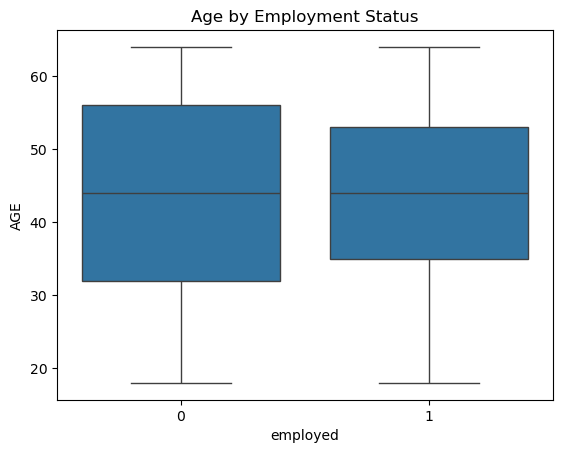

In [11]:
# Age vs Employement
sns.boxplot(x='employed', y='AGE', data=df)
plt.title('Age by Employment Status')
plt.show()

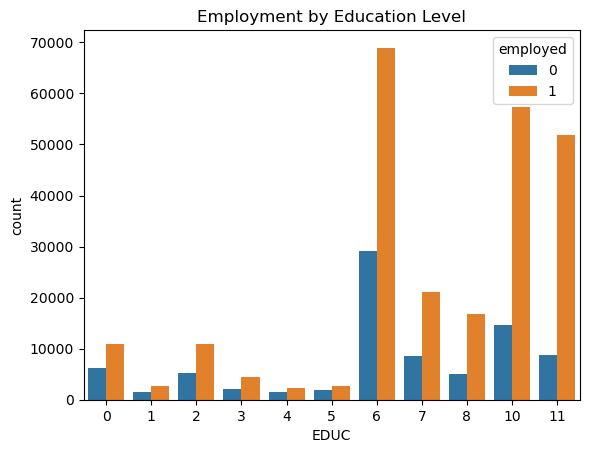

In [12]:
# Education vs Emplooyment 
sns.countplot(x='EDUC', hue='employed', data=df)
plt.title('Employment by Education Level')
plt.show()

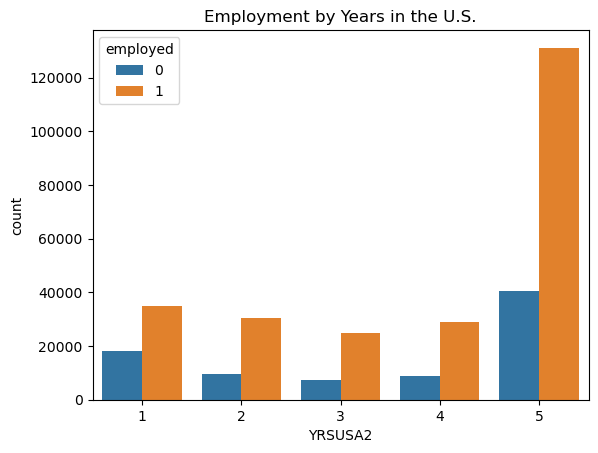

In [13]:
# Years in the US
sns.countplot(x='YRSUSA2', hue='employed', data=df)
plt.title('Employment by Years in the U.S.')
plt.show()

## Premodeling 

In [14]:
# select features
X = df[['AGE','SEX','EDUC','SPEAKENG','YRSUSA2','REGION']]
y = df['employed']

In [15]:
# One-hot encode categorical vairables
X = pd.get_dummies(X, drop_first=True)

## Model

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Unweighted model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_unweighted = model.predict(X_test)

print("Unweighted Model")
print(classification_report(y_test, y_pred_unweighted))

Unweighted Model
              precision    recall  f1-score   support

           0       0.52      0.05      0.09     25317
           1       0.75      0.98      0.85     75106

    accuracy                           0.75    100423
   macro avg       0.64      0.52      0.47    100423
weighted avg       0.70      0.75      0.66    100423



The baseline logistic regression model achieved an overall accuracy of approximately 75 percent. The model demonstrated strong performance in identifying employed individuals but showed limited ability to correctly classify individuals who were not employed. This behavior reflects the class distribution in the data and the model’s optimization toward the majority class.

In [17]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Variable,Coefficient
4,YRSUSA2,0.133954
2,EDUC,0.120137
3,SPEAKENG,0.034947
0,AGE,-0.002235
5,REGION,-0.002537
1,SEX,-0.842055


Model coefficients suggest that years in the United States and educational attainment are the strongest positive predictors of employment among foreign-born individuals. English proficiency also shows a positive association, though with a smaller effect size. Age and region exhibit minimal influence within the working-age sample. Sex displays a comparatively large association with employment outcomes, indicating notable differences in employment likelihood across sexes. All results reflect associative relationships rather than causal effects.

In [18]:
df['SEX'].value_counts(normalize=True)

SEX
2    0.515195
1    0.484805
Name: proportion, dtype: float64

The analytical sample is approximately evenly split by sex. Despite this balance, sex exhibits a strong association with employment status in the model, indicating differences in employment likelihood that persist after accounting for age, education, English proficiency, years in the United States, and region.

In [19]:
# Weighted model
weighted_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

weighted_model.fit(X_train, y_train)

y_pred_weighted = weighted_model.predict(X_test)

print("Weighted Model")
print(classification_report(y_test, y_pred_weighted))

Weighted Model
              precision    recall  f1-score   support

           0       0.35      0.62      0.45     25317
           1       0.83      0.61      0.70     75106

    accuracy                           0.61    100423
   macro avg       0.59      0.62      0.58    100423
weighted avg       0.71      0.61      0.64    100423



The unweighted logistic regression model achieved higher overall accuracy but showed limited ability to correctly identify individuals who were not employed, largely favoring the majority employed class. In contrast, applying class weighting substantially improved recall for the not-employed group, though this improvement came at the cost of reduced overall accuracy and increased misclassification of employed individuals. This comparison highlights the trade-off between optimizing for overall accuracy and achieving balanced performance across outcome classes.

## Data Visualizations

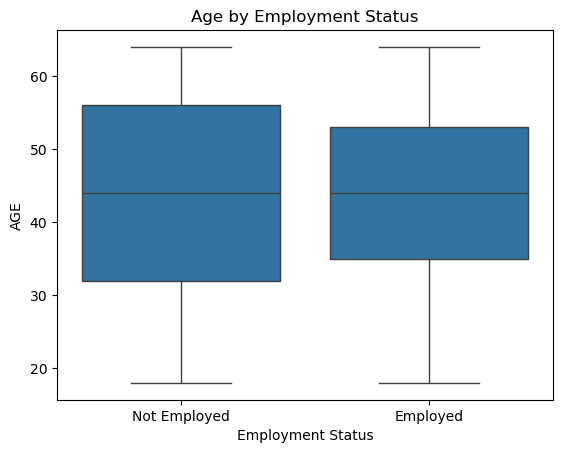

In [20]:
sns.boxplot(x='employed', y='AGE', data=df)

plt.xticks(
    ticks=[0, 1],
    labels=['Not Employed', 'Employed']
)

plt.xlabel('Employment Status')
plt.title('Age by Employment Status')

plt.show()

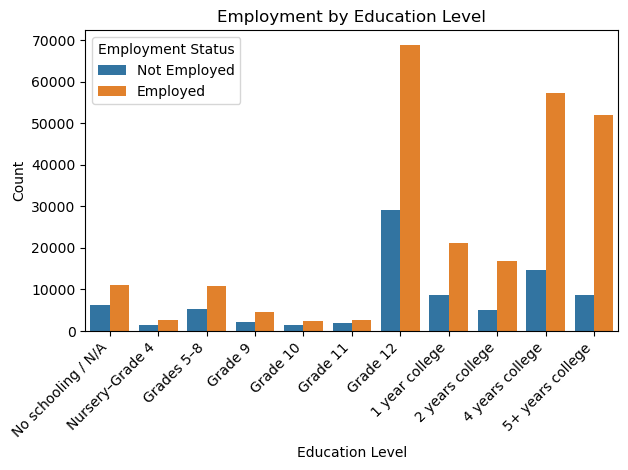

In [21]:
# Define education labels
educ_labels = {
    0: 'No schooling / N/A',
    1: 'Nursery–Grade 4',
    2: 'Grades 5–8',
    3: 'Grade 9',
    4: 'Grade 10',
    5: 'Grade 11',
    6: 'Grade 12',
    7: '1 year college',
    8: '2 years college',
    10: '4 years college',
    11: '5+ years college'
}

# Create labeled education column
df['EDUC_label'] = df['EDUC'].map(educ_labels)

# Define the order from least to most education
educ_order = [
    'No schooling / N/A',
    'Nursery–Grade 4',
    'Grades 5–8',
    'Grade 9',
    'Grade 10',
    'Grade 11',
    'Grade 12',
    '1 year college',
    '2 years college',
    '4 years college',
    '5+ years college'
]

# Plot with ordered x-axis
sns.countplot(
    x='EDUC_label',
    hue='employed',
    data=df,
    order=educ_order
)

# Labels and title
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Employment by Education Level')

# Legend labels
plt.legend(
    title='Employment Status',
    labels=['Not Employed', 'Employed']
)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

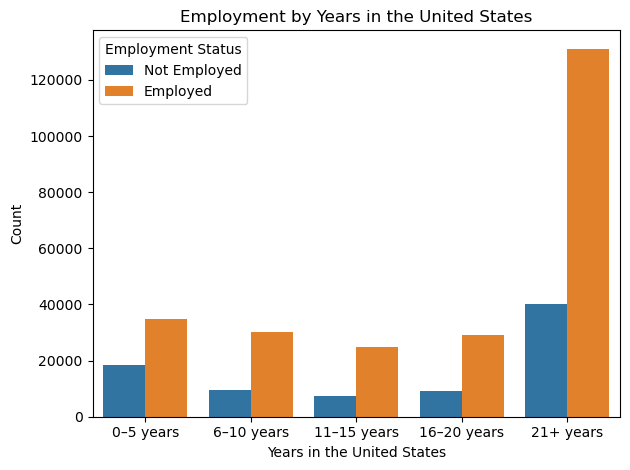

In [22]:
# Define Years in U.S. labels
yrsusa_labels = {
    0: 'N/A',
    1: '0–5 years',
    2: '6–10 years',
    3: '11–15 years',
    4: '16–20 years',
    5: '21+ years'
}

# Create labeled column
df['YRSUSA_label'] = df['YRSUSA2'].map(yrsusa_labels)

# Define order from least to most years in the U.S.
yrsusa_order = [
    '0–5 years',
    '6–10 years',
    '11–15 years',
    '16–20 years',
    '21+ years'
]

# Plot with ordered x-axis
sns.countplot(
    x='YRSUSA_label',
    hue='employed',
    data=df,
    order=yrsusa_order
)

# Axis labels and title
plt.xlabel('Years in the United States')
plt.ylabel('Count')
plt.title('Employment by Years in the United States')

# Legend labels
plt.legend(
    title='Employment Status',
    labels=['Not Employed', 'Employed']
)

# Rotate x-axis labels for readability
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

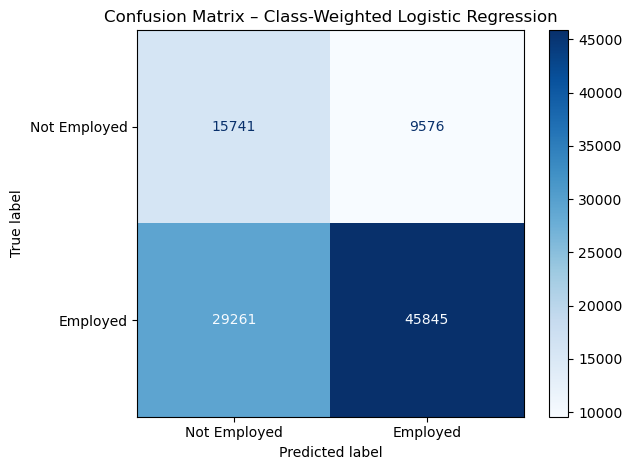

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict using the weighted model
y_pred_weighted = weighted_model.predict(X_test)

# Confusion matrix
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_weighted,
    display_labels=['Not Employed', 'Employed']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Class-Weighted Logistic Regression')
plt.tight_layout()
plt.show()

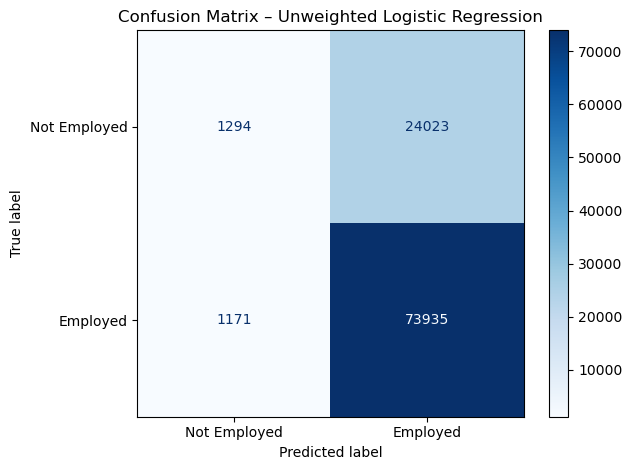

In [24]:
# Predict using unweighted model
y_pred_unweighted = model.predict(X_test)

cm_unweighted = confusion_matrix(y_test, y_pred_unweighted)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_unweighted,
    display_labels=['Not Employed', 'Employed']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Unweighted Logistic Regression')
plt.tight_layout()
plt.show()

The confusion matrices illustrate clear differences in model behavior. The unweighted model correctly classifies most employed individuals but fails to identify not-employed cases, while the class-weighted model improves detection of the not-employed group at the expense of increased misclassification among employed individuals.

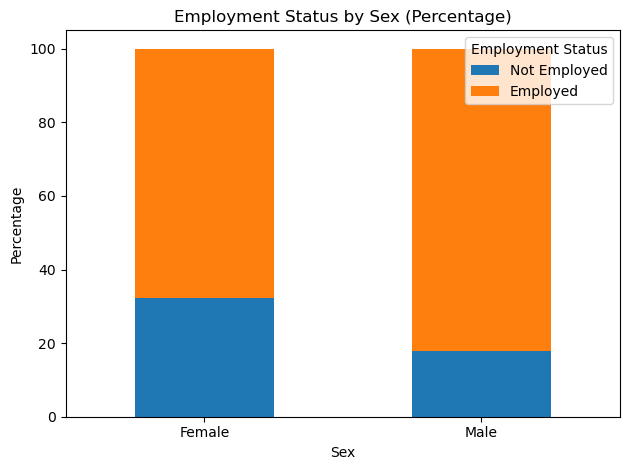

In [25]:
# Create labeled sex variable
df['SEX_label'] = df['SEX'].map({1: 'Male', 2: 'Female'})

# Create cross-tab as percentages
sex_emp = pd.crosstab(df['SEX_label'], df['employed'], normalize='index') * 100

# Rename columns
sex_emp.columns = ['Not Employed', 'Employed']

# Plot
sex_emp.plot(kind='bar', stacked=True)

plt.ylabel('Percentage')
plt.xlabel('Sex')
plt.title('Employment Status by Sex (Percentage)')

plt.legend(title='Employment Status')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
